In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
sb.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(r"../../Data/Raw/GameplayData.csv")

In [3]:
racing_metrics = [
    'lapsCompleted', 'bestLapTime', 'avgLapTime', 'totalRaceTime', 
    'collisions', 'maxSpeed', 'avgSpeed', 'consistency'
]

fighting_metrics = [
    'victory', 'combosExecuted', 'perfectDodges', 'hitsDealt', 
    'hitsTaken', 'playerAccuracy', 'avgReactionTime'
]

fighting_df = df[df['gameType']=='Fighting'].drop(columns=racing_metrics)
racing_df = df[df['gameType']=='Racing'].drop(columns=fighting_metrics)

In [4]:

print("="*60)
print("FIGHTING GAME: CREATING DERIVED FEATURES")
print("="*60)

# Make a copy for feature engineering
fighting_features = fighting_df.copy()

# --- 1. Combat Efficiency: Offensive vs Defensive Performance ---
# Measures how well player trades damage (higher = better offense/defense ratio)
fighting_features['combatEfficiency'] = (
    fighting_features['hitsDealt'] / (fighting_features['hitsTaken'] + 1)
)
print("\n✓ Created: combatEfficiency (hitsDealt / hitsTaken)")

# --- 2. Damage Output Rate ---
# Measures offensive pressure (damage per second)
fighting_features['damagePerSecond'] = (
    fighting_features['hitsDealt'] / fighting_features['sessionDuration']
)
print("✓ Created: damagePerSecond (hitsDealt / duration)")

# --- 3. Damage Intake Rate ---
# Measures how much damage player takes over time (lower = better)
fighting_features['damageIntakeRate'] = (
    fighting_features['hitsTaken'] / fighting_features['sessionDuration']
)
print("✓ Created: damageIntakeRate (hitsTaken / duration)")

# --- 4. Survival Performance ---
# Inverse of deaths - higher = better survival
fighting_features['survivalRate'] = np.where(
    fighting_features['deaths'] == 0, 
    1, 0
)
print("✓ Created: survivalRate (survived or died)")

# --- 5. Combo Execution Rate ---
# Combos per minute - measures offensive skill execution
fighting_features['comboRate'] = (
    fighting_features['combosExecuted'] / fighting_features['sessionDuration']
) * 60
print("✓ Created: comboRate (combos per minute)")

# --- 6. Perfect Dodge Rate ---
# Perfect dodges per minute - measures defensive skill
fighting_features['dodgeRate'] = (
    fighting_features['perfectDodges'] / fighting_features['sessionDuration']
) * 60
print("✓ Created: dodgeRate (perfect dodges per minute)")

# --- 7. Reaction Performance Score ---
# Inverse of reaction time (lower time = higher score = better)
# Add small epsilon to avoid division by zero
fighting_features['reactionScore'] = 1 / (fighting_features['avgReactionTime'] + 0.001)
print("✓ Created: reactionScore (1 / avgReactionTime)")

# --- 8. Overall Combat Performance Index ---
# Composite metric combining multiple aspects
fighting_features['combatPerformanceIndex'] = (
    fighting_features['playerAccuracy'] * 0.3 +
    (fighting_features['combatEfficiency'] / fighting_features['combatEfficiency'].max()) * 0.3 +
    (fighting_features['comboRate'] / fighting_features['comboRate'].max()) * 0.2 +
    (fighting_features['dodgeRate'] / fighting_features['dodgeRate'].max()) * 0.2
)
print("✓ Created: combatPerformanceIndex (weighted composite metric)")

# --- 9. Efficiency Per Accuracy ---
# How efficient player is relative to their accuracy
fighting_features['efficiencyPerAccuracy'] = (
    fighting_features['combatEfficiency'] / (fighting_features['playerAccuracy'] + 0.1)
)
print("✓ Created: efficiencyPerAccuracy")

FIGHTING GAME: CREATING DERIVED FEATURES

✓ Created: combatEfficiency (hitsDealt / hitsTaken)
✓ Created: damagePerSecond (hitsDealt / duration)
✓ Created: damageIntakeRate (hitsTaken / duration)
✓ Created: survivalRate (survived or died)
✓ Created: comboRate (combos per minute)
✓ Created: dodgeRate (perfect dodges per minute)
✓ Created: reactionScore (1 / avgReactionTime)
✓ Created: combatPerformanceIndex (weighted composite metric)
✓ Created: efficiencyPerAccuracy


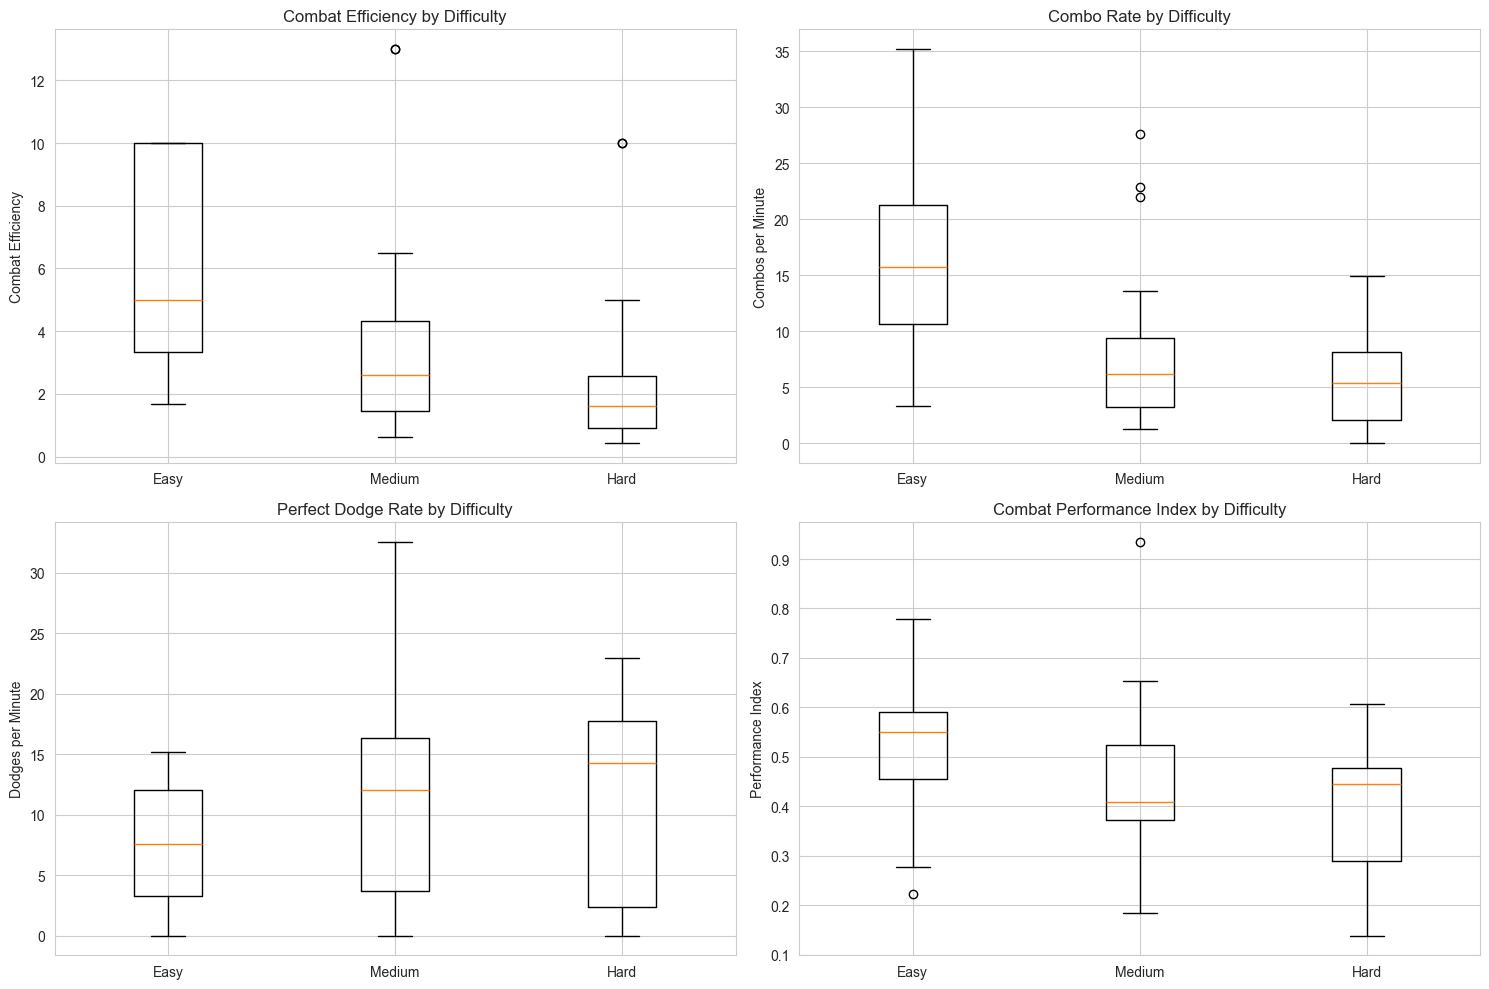

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Combat Efficiency by Difficulty
axes[0, 0].boxplot([
    fighting_features[fighting_features['difficultyLevel'] == 'Easy']['combatEfficiency'],
    fighting_features[fighting_features['difficultyLevel'] == 'Medium']['combatEfficiency'],
    fighting_features[fighting_features['difficultyLevel'] == 'Hard']['combatEfficiency']
], labels=['Easy', 'Medium', 'Hard'])
axes[0, 0].set_title('Combat Efficiency by Difficulty')
axes[0, 0].set_ylabel('Combat Efficiency')

# Combo Rate by Difficulty
axes[0, 1].boxplot([
    fighting_features[fighting_features['difficultyLevel'] == 'Easy']['comboRate'],
    fighting_features[fighting_features['difficultyLevel'] == 'Medium']['comboRate'],
    fighting_features[fighting_features['difficultyLevel'] == 'Hard']['comboRate']
], labels=['Easy', 'Medium', 'Hard'])
axes[0, 1].set_title('Combo Rate by Difficulty')
axes[0, 1].set_ylabel('Combos per Minute')

# Dodge Rate by Difficulty
axes[1, 0].boxplot([
    fighting_features[fighting_features['difficultyLevel'] == 'Easy']['dodgeRate'],
    fighting_features[fighting_features['difficultyLevel'] == 'Medium']['dodgeRate'],
    fighting_features[fighting_features['difficultyLevel'] == 'Hard']['dodgeRate']
], labels=['Easy', 'Medium', 'Hard'])
axes[1, 0].set_title('Perfect Dodge Rate by Difficulty')
axes[1, 0].set_ylabel('Dodges per Minute')

# Combat Performance Index by Difficulty
axes[1, 1].boxplot([
    fighting_features[fighting_features['difficultyLevel'] == 'Easy']['combatPerformanceIndex'],
    fighting_features[fighting_features['difficultyLevel'] == 'Medium']['combatPerformanceIndex'],
    fighting_features[fighting_features['difficultyLevel'] == 'Hard']['combatPerformanceIndex']
], labels=['Easy', 'Medium', 'Hard'])
axes[1, 1].set_title('Combat Performance Index by Difficulty')
axes[1, 1].set_ylabel('Performance Index')

plt.tight_layout()
# plt.savefig('../reports/figures/fighting_engineered_features.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("\n" + "="*60)
print("FIGHTING GAME: SAMPLE OF ENGINEERED FEATURES")
print("="*60)

display_cols = ['playerID', 'difficultyLevel', 'victory', 'playerAccuracy',
                'combatEfficiency', 'damagePerSecond', 'comboRate', 
                'dodgeRate', 'reactionScore', 'combatPerformanceIndex']

print(fighting_features[display_cols].head(10))


FIGHTING GAME: SAMPLE OF ENGINEERED FEATURES
    playerID difficultyLevel victory  playerAccuracy  combatEfficiency  \
0          1            Easy    True        1.000000         10.000000   
1          1          Medium    True        1.000000          4.333333   
2          1            Hard    True        0.909091         10.000000   
6          2            Easy    True        0.833333          3.333333   
7          2          Medium   False        0.538462          0.636364   
8          2            Hard   False        0.444444          1.142857   
12         3            Easy    True        0.476191          3.333333   
13         3          Medium   False        0.625000          0.909091   
14         3            Hard   False        0.428571          0.428571   
18         4            Easy    True        0.833333         10.000000   

    damagePerSecond  comboRate  dodgeRate  reactionScore  \
0          0.619579  22.304833  11.152416       1.132134   
1          0.392394

In [7]:
print("\n" + "="*60)
print("FIGHTING GAME: ENGINEERED FEATURES SUMMARY")
print("="*60)

engineered_cols = ['combatEfficiency', 'damagePerSecond', 'damageIntakeRate', 
                   'survivalRate', 'comboRate', 'dodgeRate', 'reactionScore',
                   'combatPerformanceIndex', 'efficiencyPerAccuracy']

print(fighting_features[engineered_cols].describe())


FIGHTING GAME: ENGINEERED FEATURES SUMMARY
       combatEfficiency  damagePerSecond  damageIntakeRate  survivalRate  \
count         90.000000        90.000000         90.000000     90.000000   
mean           3.876206         0.354383          0.116797      0.666667   
std            3.235170         0.126650          0.096421      0.474045   
min            0.428571         0.024521          0.000000      0.000000   
25%            1.444444         0.266531          0.047813      0.000000   
50%            2.657143         0.332456          0.089279      1.000000   
75%            5.000000         0.433149          0.187170      1.000000   
max           13.000000         0.651890          0.372960      1.000000   

       comboRate  dodgeRate  reactionScore  combatPerformanceIndex  \
count  90.000000  90.000000      90.000000               90.000000   
mean    9.862855  10.027240     169.494693                0.455846   
std     7.724586   7.310624     373.528239                0.1

In [8]:
print("="*60)
print("RACING GAME: CREATING DERIVED FEATURES")
print("="*60)

# Make a copy for feature engineering
racing_features = racing_df.copy()

# --- 1. Speed Efficiency ---
# How well player utilizes maximum speed potential
racing_features['speedEfficiency'] = (
    racing_features['avgSpeed'] / (racing_features['maxSpeed'] + 1)
)
print("\n✓ Created: speedEfficiency (avgSpeed / maxSpeed)")

# --- 2. Collision Rate ---
# Collisions per lap - measures control and obstacle avoidance
racing_features['collisionRate'] = (
    racing_features['collisions'] / (racing_features['lapsCompleted'] + 1)
)
print("✓ Created: collisionRate (collisions per lap)")

# --- 3. Lap Time Variance ---
# Difference between best and average lap - measures consistency
racing_features['lapTimeVariance'] = (
    racing_features['avgLapTime'] - racing_features['bestLapTime']
)
print("✓ Created: lapTimeVariance (avgLap - bestLap)")

# --- 4. Completion Rate ---
# Laps completed per minute - measures speed of completion
racing_features['completionRate'] = (
    racing_features['lapsCompleted'] / racing_features['sessionDuration']
) * 60
print("✓ Created: completionRate (laps per minute)")

# --- 5. Driving Smoothness ---
# Inverse of collision rate - higher = smoother driving
racing_features['drivingSmoothness'] = 1 / (racing_features['collisionRate'] + 0.1)
print("✓ Created: drivingSmoothness (1 / collisionRate)")

# --- 6. Time Efficiency ---
# How close average lap is to best lap (closer to 1 = more consistent)
racing_features['timeEfficiency'] = (
    racing_features['bestLapTime'] / (racing_features['avgLapTime'] + 0.001)
)
print("✓ Created: timeEfficiency (bestLap / avgLap)")

# --- 7. Speed Consistency Score ---
# Combines speed efficiency with consistency metric
racing_features['speedConsistencyScore'] = (
    racing_features['speedEfficiency'] * racing_features['consistency']
)
print("✓ Created: speedConsistencyScore (speedEff × consistency)")

# --- 8. Overall Racing Performance Index ---
# Composite metric combining multiple aspects
racing_features['racingPerformanceIndex'] = (
    (racing_features['completionRate'] / racing_features['completionRate'].max()) * 0.3 +
    racing_features['speedEfficiency'] * 0.25 +
    racing_features['consistency'] * 0.25 +
    (racing_features['drivingSmoothness'] / racing_features['drivingSmoothness'].max()) * 0.2
)
print("✓ Created: racingPerformanceIndex (weighted composite metric)")

# --- 9. Clean Racing Score ---
# Measures clean racing (low collisions + high consistency)
racing_features['cleanRacingScore'] = (
    racing_features['drivingSmoothness'] * racing_features['consistency']
)
print("✓ Created: cleanRacingScore (smoothness × consistency)")

RACING GAME: CREATING DERIVED FEATURES

✓ Created: speedEfficiency (avgSpeed / maxSpeed)
✓ Created: collisionRate (collisions per lap)
✓ Created: lapTimeVariance (avgLap - bestLap)
✓ Created: completionRate (laps per minute)
✓ Created: drivingSmoothness (1 / collisionRate)
✓ Created: timeEfficiency (bestLap / avgLap)
✓ Created: speedConsistencyScore (speedEff × consistency)
✓ Created: racingPerformanceIndex (weighted composite metric)
✓ Created: cleanRacingScore (smoothness × consistency)


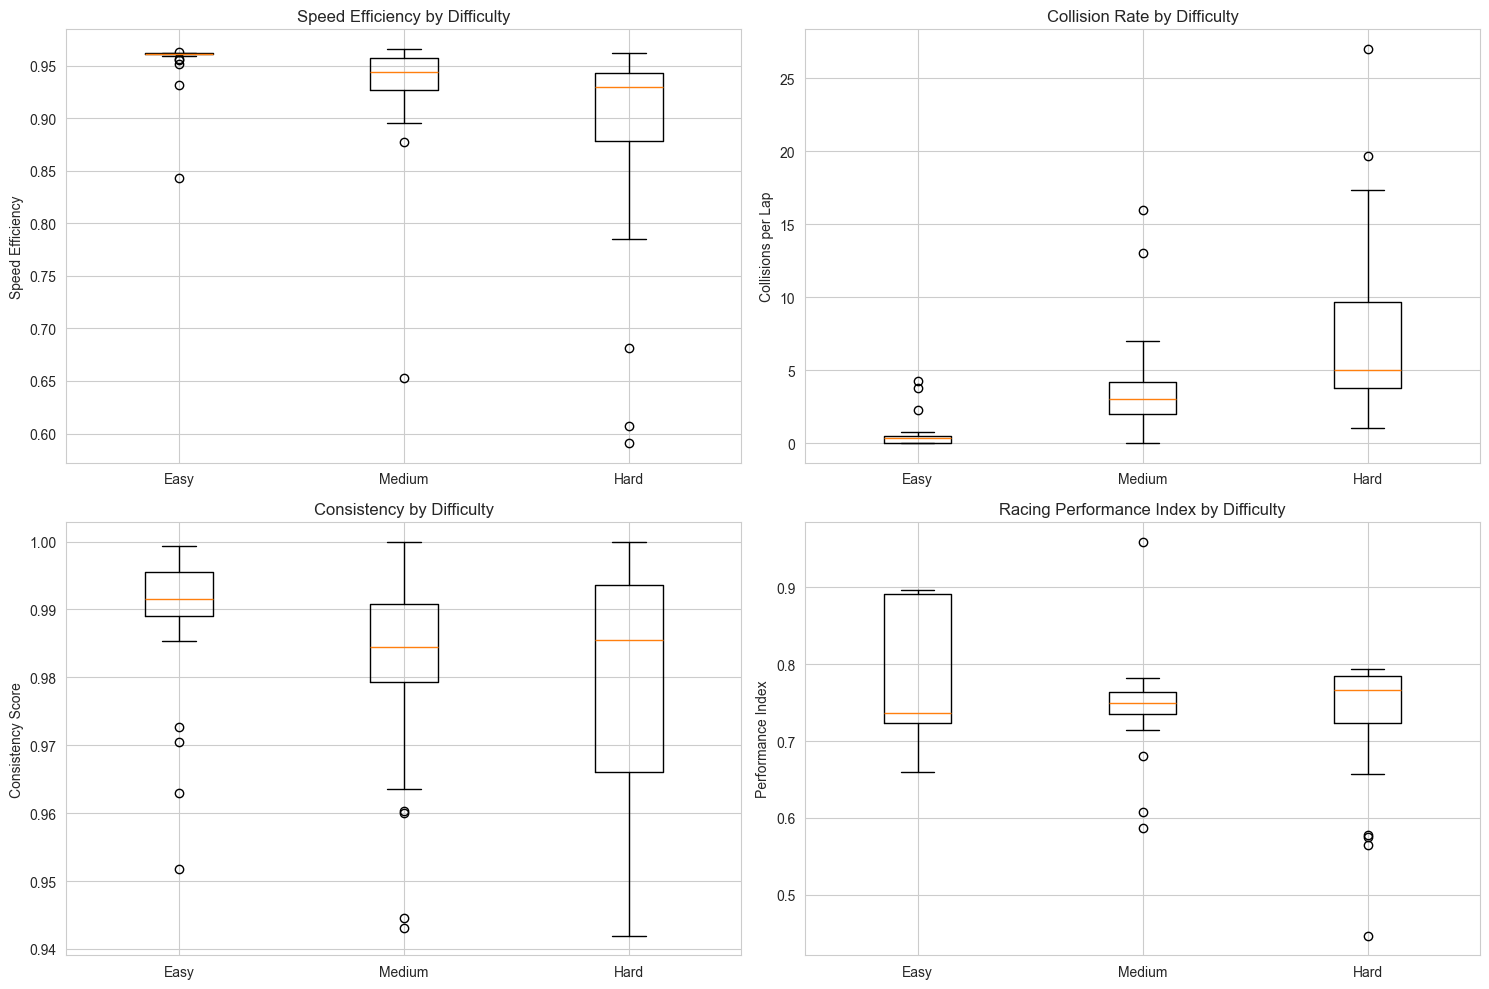

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Speed Efficiency by Difficulty
axes[0, 0].boxplot([
    racing_features[racing_features['difficultyLevel'] == 'Easy']['speedEfficiency'],
    racing_features[racing_features['difficultyLevel'] == 'Medium']['speedEfficiency'],
    racing_features[racing_features['difficultyLevel'] == 'Hard']['speedEfficiency']
], labels=['Easy', 'Medium', 'Hard'])
axes[0, 0].set_title('Speed Efficiency by Difficulty')
axes[0, 0].set_ylabel('Speed Efficiency')

# Collision Rate by Difficulty
axes[0, 1].boxplot([
    racing_features[racing_features['difficultyLevel'] == 'Easy']['collisionRate'],
    racing_features[racing_features['difficultyLevel'] == 'Medium']['collisionRate'],
    racing_features[racing_features['difficultyLevel'] == 'Hard']['collisionRate']
], labels=['Easy', 'Medium', 'Hard'])
axes[0, 1].set_title('Collision Rate by Difficulty')
axes[0, 1].set_ylabel('Collisions per Lap')

# Consistency by Difficulty
axes[1, 0].boxplot([
    racing_features[racing_features['difficultyLevel'] == 'Easy']['consistency'],
    racing_features[racing_features['difficultyLevel'] == 'Medium']['consistency'],
    racing_features[racing_features['difficultyLevel'] == 'Hard']['consistency']
], labels=['Easy', 'Medium', 'Hard'])
axes[1, 0].set_title('Consistency by Difficulty')
axes[1, 0].set_ylabel('Consistency Score')

# Racing Performance Index by Difficulty
axes[1, 1].boxplot([
    racing_features[racing_features['difficultyLevel'] == 'Easy']['racingPerformanceIndex'],
    racing_features[racing_features['difficultyLevel'] == 'Medium']['racingPerformanceIndex'],
    racing_features[racing_features['difficultyLevel'] == 'Hard']['racingPerformanceIndex']
], labels=['Easy', 'Medium', 'Hard'])
axes[1, 1].set_title('Racing Performance Index by Difficulty')
axes[1, 1].set_ylabel('Performance Index')

plt.tight_layout()
# plt.savefig('../reports/figures/racing_engineered_features.png', dpi=300, bbox_inches='tight')
plt.show()

# print("✓ Visualizations saved")

In [10]:
print("\n" + "="*60)
print("RACING GAME: SAMPLE OF ENGINEERED FEATURES")
print("="*60)

display_cols = ['playerID', 'difficultyLevel', 'completed', 'bestLapTime',
                'speedEfficiency', 'collisionRate', 'completionRate',
                'consistency', 'racingPerformanceIndex']

print(racing_features[display_cols].head(10))


RACING GAME: SAMPLE OF ENGINEERED FEATURES
    playerID difficultyLevel  completed  bestLapTime  speedEfficiency  \
3          1            Easy       True     50.57998         0.961526   
4          1          Medium       True     39.57999         0.918108   
5          1            Hard       True     35.01999         0.914992   
9          2            Easy       True     56.61655         0.842819   
10         2          Medium       True     57.81998         0.652850   
11         2            Hard       True     53.77833         0.590885   
15         3            Easy       True     51.07999         0.931812   
16         3          Medium      False     43.47988         0.877350   
17         3            Hard      False     55.89474         0.606792   
21         4            Easy       True     50.05998         0.955894   

    collisionRate  completionRate  consistency  racingPerformanceIndex  
3        0.250000        1.176163     0.990413                0.748133  
4     

In [11]:
print("\n" + "="*60)
print("RACING GAME: ENGINEERED FEATURES SUMMARY")
print("="*60)

racing_engineered_cols = ['speedEfficiency', 'collisionRate', 'lapTimeVariance',
                          'completionRate', 'drivingSmoothness', 'timeEfficiency',
                          'speedConsistencyScore', 'racingPerformanceIndex', 'cleanRacingScore']

print(racing_features[racing_engineered_cols].describe())


RACING GAME: ENGINEERED FEATURES SUMMARY
       speedEfficiency  collisionRate  lapTimeVariance  completionRate  \
count        90.000000      90.000000        90.000000       90.000000   
mean          0.924642       3.837963         0.755958        1.384605   
std           0.072860       4.690488         0.693438        0.282458   
min           0.590885       0.000000         0.000000        0.000000   
25%           0.928808       0.500000         0.267660        1.175261   
50%           0.950121       2.750000         0.541720        1.482471   
75%           0.961127       4.500000         1.042193        1.571848   
max           0.965850      27.000000         3.774430        1.738123   

       drivingSmoothness  timeEfficiency  speedConsistencyScore  \
count          90.000000       90.000000              90.000000   
mean            1.960670        0.971113               0.909430   
std             3.382067        0.104611               0.075257   
min             0.03690

FIGHTING GAME: CORRELATION ANALYSIS


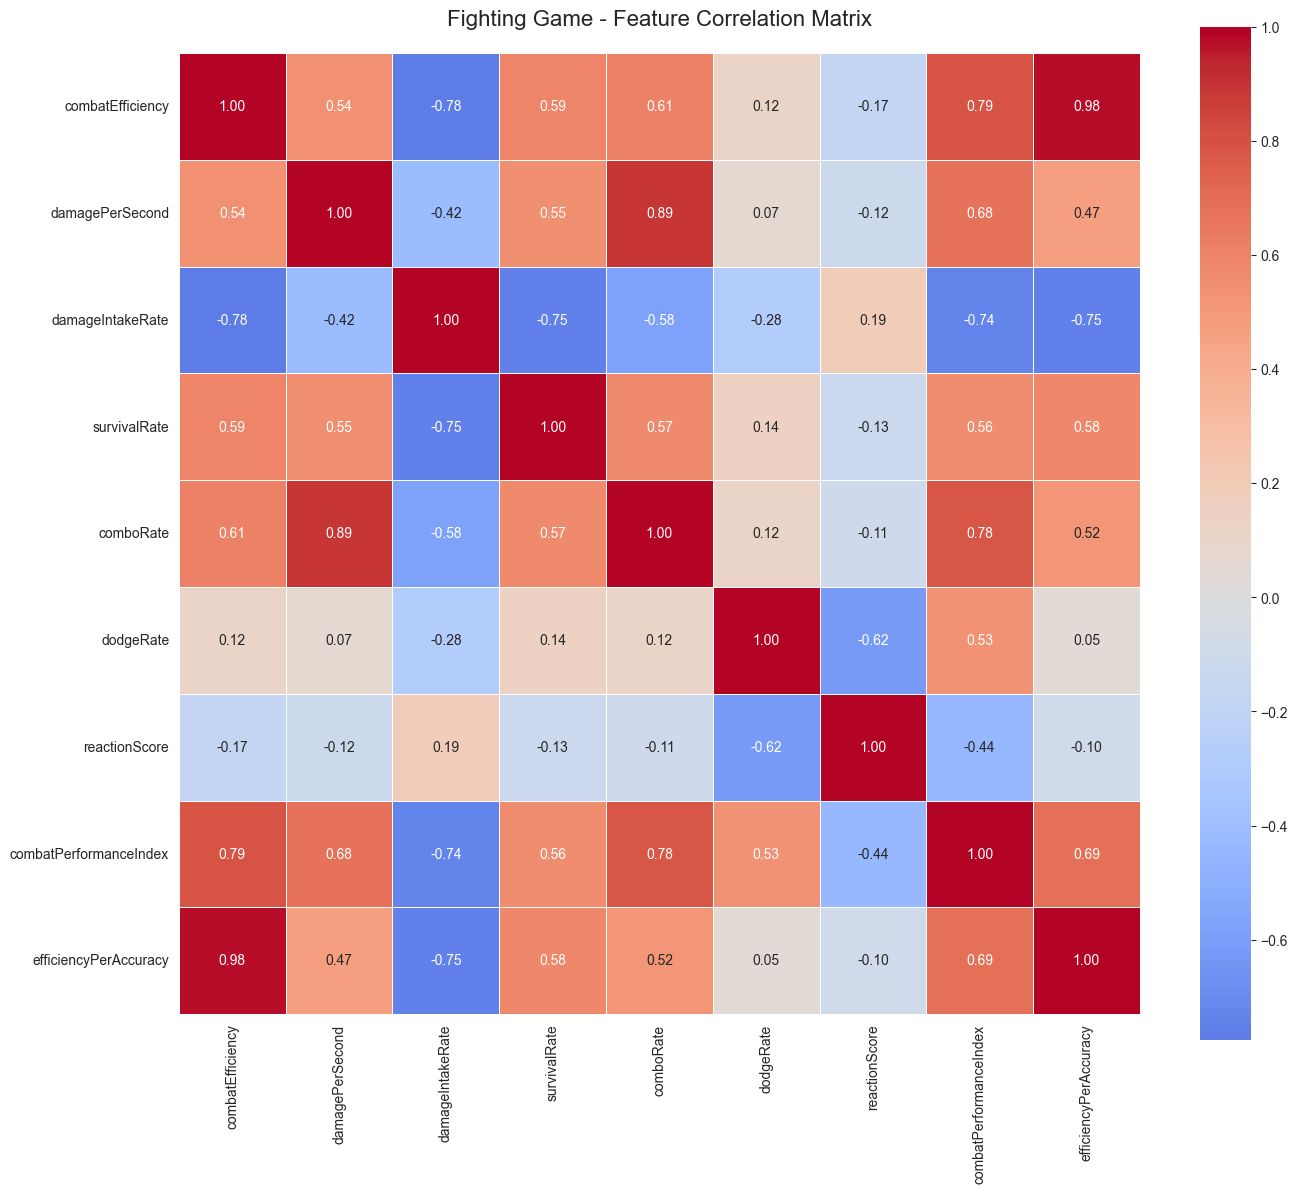

In [12]:
print("="*60)
print("FIGHTING GAME: CORRELATION ANALYSIS")
print("="*60)

# Select only numeric features for correlation
fighting_numeric = fighting_features[engineered_cols]

# Remove ID columns
cols_to_exclude = ['sessionID', 'playerID']
fighting_numeric = fighting_numeric.drop(
    columns=[col for col in cols_to_exclude if col in fighting_numeric.columns]
)

# Create correlation matrix
plt.figure(figsize=(14, 12))
correlation_matrix = fighting_numeric.corr()
sb.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Fighting Game - Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
# plt.savefig('../reports/figures/fighting_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
print("-" * 60)

high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated pairs found (good - features are relatively independent!)")


Highly Correlated Feature Pairs (|r| > 0.8):
------------------------------------------------------------
       Feature 1             Feature 2  Correlation
combatEfficiency efficiencyPerAccuracy     0.977359
 damagePerSecond             comboRate     0.890878



RACING GAME: CORRELATION ANALYSIS


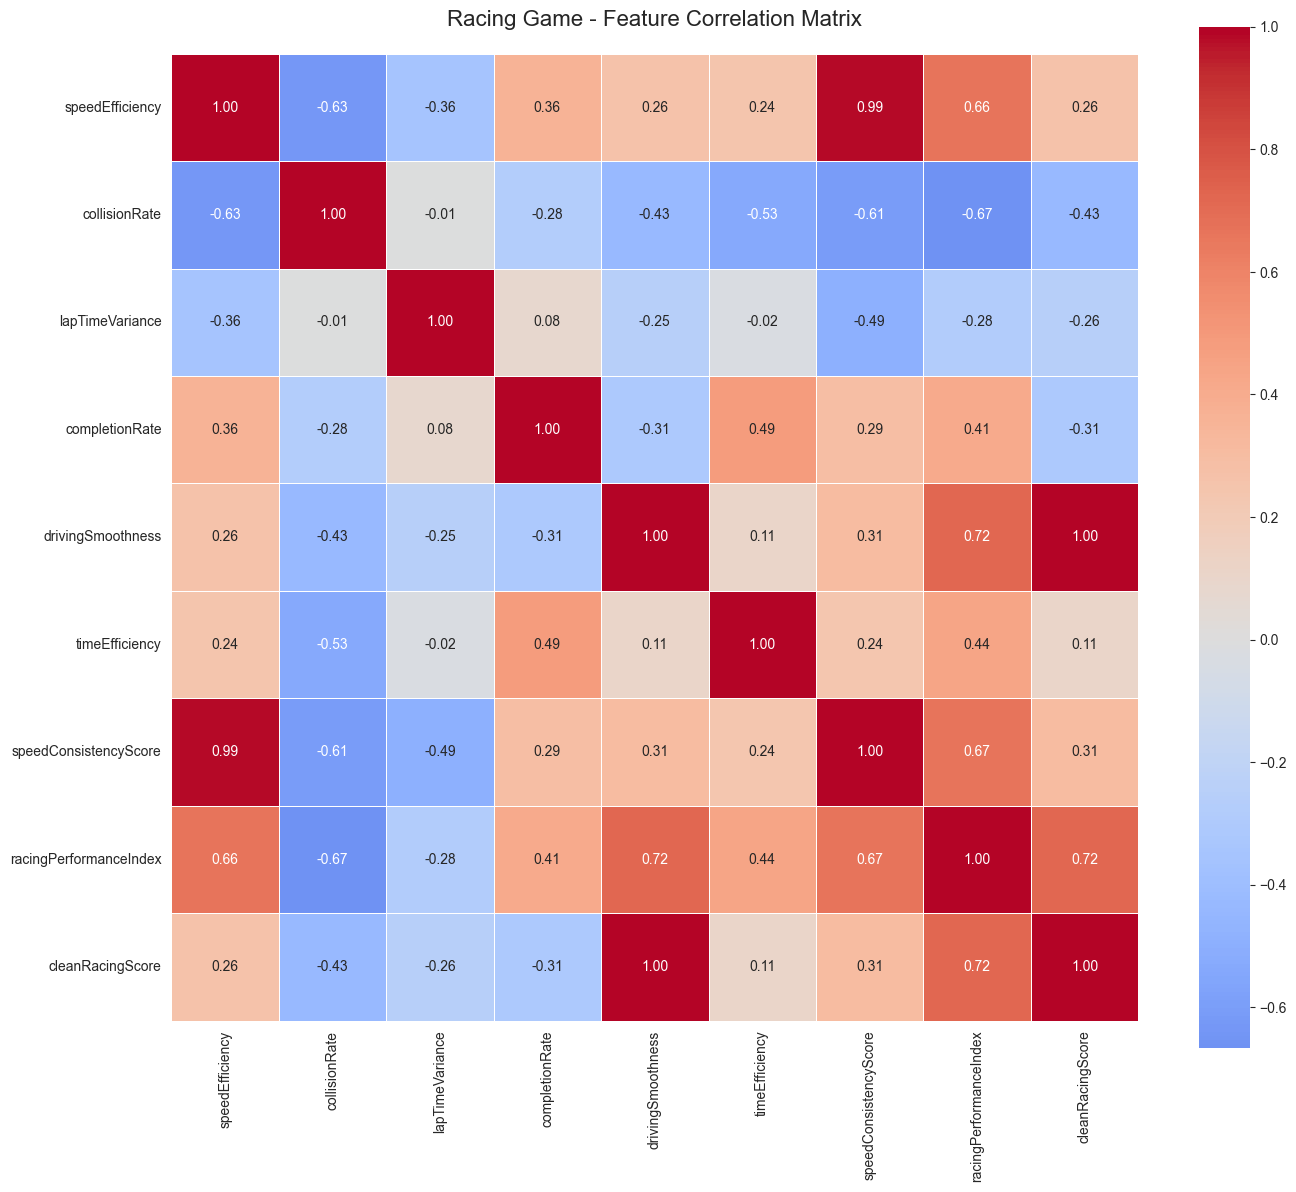

In [14]:
print("\n" + "="*60)
print("RACING GAME: CORRELATION ANALYSIS")
print("="*60)

# Select only numeric features for correlation
racing_numeric = racing_features[racing_engineered_cols]

# Remove ID columns
racing_numeric = racing_numeric.drop(
    columns=[col for col in cols_to_exclude if col in racing_numeric.columns]
)

# Create correlation matrix
plt.figure(figsize=(14, 12))
correlation_matrix_racing = racing_numeric.corr()
sb.heatmap(correlation_matrix_racing, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Racing Game - Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
# plt.savefig('../reports/figures/racing_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
print("-" * 60)

high_corr_racing = []
for i in range(len(correlation_matrix_racing.columns)):
    for j in range(i+1, len(correlation_matrix_racing.columns)):
        if abs(correlation_matrix_racing.iloc[i, j]) > 0.8:
            high_corr_racing.append({
                'Feature 1': correlation_matrix_racing.columns[i],
                'Feature 2': correlation_matrix_racing.columns[j],
                'Correlation': correlation_matrix_racing.iloc[i, j]
            })

if high_corr_racing:
    high_corr_racing_df = pd.DataFrame(high_corr_racing)
    print(high_corr_racing_df.to_string(index=False))
else:
    print("No highly correlated pairs found (good - features are relatively independent!)")


Highly Correlated Feature Pairs (|r| > 0.8):
------------------------------------------------------------
        Feature 1             Feature 2  Correlation
  speedEfficiency speedConsistencyScore     0.986171
drivingSmoothness      cleanRacingScore     0.999986


In [16]:
output_dir = Path('../../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Save fighting game features (WITHOUT labels)
fighting_output_path = output_dir / 'fighting_features.csv'
fighting_features.to_csv(fighting_output_path, index=False)
print(f"✓ Saved: {fighting_output_path}")
print(f"  Shape: {fighting_features.shape}")

# Save racing game features (WITHOUT labels)
racing_output_path = output_dir / 'racing_features.csv'
racing_features.to_csv(racing_output_path, index=False)
print(f"✓ Saved: {racing_output_path}")
print(f"  Shape: {racing_features.shape}")

✓ Saved: ..\..\data\processed\fighting_features.csv
  Shape: (90, 25)
✓ Saved: ..\..\data\processed\racing_features.csv
  Shape: (90, 26)


In [17]:
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\n{'FIGHTING GAME':-^70}")
print(f"Original sessions: {len(fighting_df)}")
print(f"Features after engineering: {len(fighting_features.columns)}")
print(f"\nBase features: {len([col for col in fighting_features.columns if col in fighting_df.columns])}")
print(f"Engineered features: {len(engineered_cols)}")

print(f"\nEngineered features created:")
for i, col in enumerate(engineered_cols, 1):
    print(f"  {i}. {col}")

print(f"\n{'RACING GAME':-^70}")
print(f"Original sessions: {len(racing_df)}")
print(f"Features after engineering: {len(racing_features.columns)}")
print(f"\nBase features: {len([col for col in racing_features.columns if col in racing_df.columns])}")
print(f"Engineered features: {len(racing_engineered_cols)}")

print(f"\nEngineered features created:")
for i, col in enumerate(racing_engineered_cols, 1):
    print(f"  {i}. {col}")

print(f"\n{'OUTPUT FILES':-^70}")
print(f"✓ fighting_features.csv → {len(fighting_features)} rows × {len(fighting_features.columns)} columns")
print(f"✓ racing_features.csv → {len(racing_features)} rows × {len(racing_features.columns)} columns")

print(f"\n{'NEXT STEPS':-^70}")
print("1. Open label_generation.ipynb")
print("2. Create ground truth labels using Flow Theory")
print("3. Address circular reasoning concerns")
print("4. Validate label distribution")

print("="*70)


FEATURE ENGINEERING SUMMARY

----------------------------FIGHTING GAME-----------------------------
Original sessions: 90
Features after engineering: 25

Base features: 16
Engineered features: 9

Engineered features created:
  1. combatEfficiency
  2. damagePerSecond
  3. damageIntakeRate
  4. survivalRate
  5. comboRate
  6. dodgeRate
  7. reactionScore
  8. combatPerformanceIndex
  9. efficiencyPerAccuracy

-----------------------------RACING GAME------------------------------
Original sessions: 90
Features after engineering: 26

Base features: 17
Engineered features: 9

Engineered features created:
  1. speedEfficiency
  2. collisionRate
  3. lapTimeVariance
  4. completionRate
  5. drivingSmoothness
  6. timeEfficiency
  7. speedConsistencyScore
  8. racingPerformanceIndex
  9. cleanRacingScore

-----------------------------OUTPUT FILES-----------------------------
✓ fighting_features.csv → 90 rows × 25 columns
✓ racing_features.csv → 90 rows × 26 columns

------------------------